In [1]:

import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions
     

In [2]:
df = pd.DataFrame()

In [4]:
df

""


In [5]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [6]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


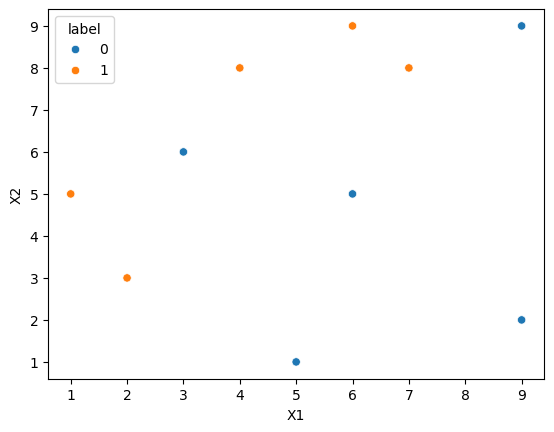

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x = df['X1'] , y = df['X2'] , hue = df['label']) 
plt.show()

In [8]:
df['weights'] = 1 / df.shape[0]

In [9]:
df


,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [10]:

from sklearn.tree import DecisionTreeClassifier

In [14]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [15]:
X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [16]:
dt1.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

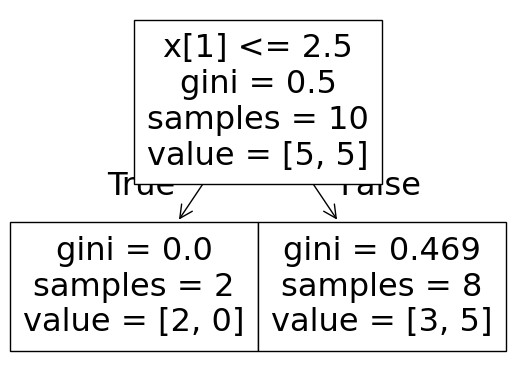

In [17]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

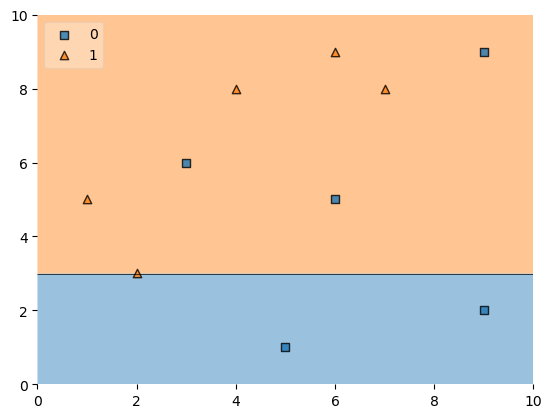

In [18]:
plot_decision_regions(X, y, clf=dt1, legend=2)

In [20]:
df['y_pred'] = dt1.predict(X)

In [21]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [22]:
def calculate_model_weight(error):

  return 0.5*np.log((1-error)/(error))

In [23]:
alpha1 = calculate_model_weight(0.3)

In [24]:
alpha1

0.42364893019360184

In [25]:
def update_row_weights(row,alpha=0.423):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)
      # this will automatically boost the weight of incorrectly classified rows and lower the weight of correclty classified pts

In [26]:
df['updated_weights'] = df.apply(update_row_weights,axis=1)

In [28]:
df['updated_weights'].sum()

0.9165153319682015

In [29]:
df['normalized_weights'] = df['updated_weights']/df['updated_weights'].sum()

In [31]:
df['normalized_weights'].sum() # achieved

1.0

In [33]:
df['cumsum_upper'] = np.cumsum(df['normalized_weights'])


In [35]:
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']

In [36]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,1,0.152653,0.166559,0.309508,0.142950
3,4,8,1,0.1,1,0.065508,0.071475,0.380983,0.309508
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,1,0.065508,0.071475,0.523933,0.452458
6,6,5,0,0.1,1,0.152653,0.166559,0.690492,0.523933
7,7,8,1,0.1,1,0.065508,0.071475,0.761967,0.690492
8,9,9,0,0.1,1,0.152653,0.166559,0.928525,0.761967
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


In [37]:
df[['X1','X2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,1,0.152653,0.142950,0.309508
3,4,8,1,0.1,1,0.065508,0.309508,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,1,0.065508,0.452458,0.523933
6,6,5,0,0.1,1,0.152653,0.523933,0.690492
7,7,8,1,0.1,1,0.065508,0.690492,0.761967
8,9,9,0,0.1,1,0.152653,0.761967,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [38]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,1,0.152653,0.166559,0.309508,0.142950
3,4,8,1,0.1,1,0.065508,0.071475,0.380983,0.309508
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,1,0.065508,0.071475,0.523933,0.452458
6,6,5,0,0.1,1,0.152653,0.166559,0.690492,0.523933
7,7,8,1,0.1,1,0.065508,0.071475,0.761967,0.690492
8,9,9,0,0.1,1,0.152653,0.166559,0.928525,0.761967
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


In [39]:
def create_new_dataset(df):
    indices = []
    for i in range(df.shape[0]):
        a = np.random.random()
        for index, row in df.iterrows():
            if row['cumsum_upper'] > a and row['cumsum_lower'] < a:
                indices.append(index)
    return indices

In [40]:
index_values = create_new_dataset(df)

In [41]:
index_values

[1, 6, 2, 9, 2, 0, 1, 6, 0, 4]

In [42]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [43]:
second_df

,X1,X2,label,weights
1,2,3,1,0.1
6,6,5,0,0.1
2,3,6,0,0.1
9,9,2,0,0.1
2,3,6,0,0.1
0,1,5,1,0.1
1,2,3,1,0.1
6,6,5,0,0.1
0,1,5,1,0.1
4,5,1,0,0.1


## `This is the Complete intution of what going on in one iteration of AdaBoost Algorithm and finally we used formula [sign(alpha1 * h1(x) + alpha2 * h2(x) + alpha3 * h3(x))] if the sign is positive we infer that point belongs to positive class and if sign negative VICE VERSA`